# Analyze Factors Influencing Airbnb Listing Price in NYC

**Authors:** Wendy Fu & Kerry Zhang

We use the Inside Airbnb New York City listings snapshot (November 1, 2025) to look at how nightly listing price varies with location, room type, host behavior, and review metrics, and then train a few regression models to predict price. The questions below guide the analysis.

## 1. Project Goals

1. How does nightly price differ across boroughs, neighborhoods, and room types?
2. Which features (capacity, reviews, host behavior, availability) line up with price?
3. Are borough-level price differences statistically meaningful?
4. Can simple regression models from class beat a naive baseline at predicting price?
5. Inside the best model, which features end up being the most useful predictors?

We focus on association, not causation. The dataset is one snapshot, so results describe listed prices rather than booked revenue.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme()
plt.rcParams["figure.figsize"] = (10, 6)

## 2. Load Data

The file is the detailed listings table from Inside Airbnb. It contains listing characteristics, host attributes, location columns, availability, and review metrics.

In [2]:
df = pd.read_csv("listings.csv", low_memory=False)
print("Rows and columns:", df.shape)
df.head()

Rows and columns: (36353, 79)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,1274691077561855573,https://www.airbnb.com/rooms/1274691077561855573,20251101201932,2025-11-02,city scrape,Beautiful room for rent hosted by Svitlana,Cozy Room for Rent in a Two-Bedroom Apartment<...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,658783772,...,5.0,5.0,5.0,OSE-STRREG-0002773,f,1,0,1,0,1.62
1,1274722590671904755,https://www.airbnb.com/rooms/1274722590671904755,20251101201932,2025-11-02,city scrape,Exquisite & Charming Studio in Prime Locations,This stylish place to stay is perfect for grou...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,458668555,...,5.0,4.5,5.0,NaN,f,6,0,6,0,0.21
2,1274773188072371454,https://www.airbnb.com/rooms/1274773188072371454,20251101201932,2025-11-02,city scrape,"Private 2 Bedroom Unit, Full Kitchen, Washer/D...",This stylish place to stay is perfect for trav...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,22369387,...,NaN,NaN,NaN,NaN,f,3,2,1,0,NaN
3,1274820999428562667,https://www.airbnb.com/rooms/1274820999428562667,20251101201932,2025-11-02,city scrape,"Beautiful, Serene West Village Treehouse",Switch off in this serene one-bedroom oasis on...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,505544503,...,NaN,NaN,NaN,NaN,f,1,1,0,0,NaN
4,1274826163511555978,https://www.airbnb.com/rooms/1274826163511555978,20251101201932,2025-11-02,city scrape,Renovated 1BR w/ Spa Shower,Newly renovated 1-bedroom oasis in vibrant Dow...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,493151605,...,5.0,4.0,5.0,NaN,f,4,2,2,0,0.10


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36353 entries, 0 to 36352
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            36353 non-null  int64  
 1   listing_url                                   36353 non-null  object 
 2   scrape_id                                     36353 non-null  int64  
 3   last_scraped                                  36353 non-null  object 
 4   source                                        36353 non-null  object 
 5   name                                          36351 non-null  object 
 6   description                                   35178 non-null  object 
 7   neighborhood_overview                         18748 non-null  object 
 8   picture_url                                   36353 non-null  object 
 9   host_id                                       36353 non-null 

## 3. Data Cleaning

The `price` column is stored as text like `$87.00`, so it has to be converted to a number. Listings without a price cannot be used for price prediction and are dropped. Airbnb prices are also heavily right-skewed; a few extreme listings can dominate averages and regression coefficients, so we trim the bottom and top 1% of prices.

In [4]:
data = df.copy()

# price is stored as text with $ and commas
data["price"] = (data["price"].astype(str)
                              .str.replace("$", "", regex=False)
                              .str.replace(",", "", regex=False))
data["price"] = pd.to_numeric(data["price"], errors="coerce")

print("Original rows:", len(data))
print("Listings with a usable price:", data["price"].notna().sum())
print("Missing price share:", round(data["price"].isna().mean() * 100, 2), "%")

data = data.dropna(subset=["price"])
data = data[data["price"] > 0]

lower_price = data["price"].quantile(0.01)
upper_price = data["price"].quantile(0.99)
data = data[(data["price"] >= lower_price) & (data["price"] <= upper_price)]

print("Rows after price cleaning:", len(data))
print("Kept price range: $", round(lower_price, 2), "to $", round(upper_price, 2))

Original rows: 36353
Listings with a usable price: 21415
Missing price share: 41.09 %
Rows after price cleaning: 21011
Kept price range: $ 36.0 to $ 2266.16


In [5]:
# percentage columns are also text
for col in ["host_response_rate", "host_acceptance_rate"]:
    data[col] = data[col].astype(str).str.replace("%", "", regex=False)
    data[col] = pd.to_numeric(data[col], errors="coerce")

# t/f columns -> 1/0
for col in ["host_is_superhost", "host_has_profile_pic",
            "host_identity_verified", "instant_bookable"]:
    data[col] = data[col].map({"t": 1, "f": 0})

# years on the platform, anchored to the snapshot date
snapshot_date = pd.Timestamp("2025-11-01")
data["host_since"] = pd.to_datetime(data["host_since"], errors="coerce")
data["host_years"] = (snapshot_date - data["host_since"]).dt.days / 365.25

data["has_license"] = data["license"].notna().astype(int)
data["amenities_count"] = (data["amenities"].fillna("")
                                             .apply(lambda x: 0 if x == "" else x.count(",") + 1))

data[["price", "host_response_rate", "host_acceptance_rate",
      "host_years", "amenities_count"]].head()

,price,host_response_rate,host_acceptance_rate,host_years,amenities_count
0,87.0,100.0,97.0,1.021218,11
1,80.0,100.0,100.0,3.477070,51
2,99.0,100.0,67.0,11.060917,34
3,312.0,50.0,20.0,2.633812,32
4,111.0,100.0,100.0,2.844627,30


## 4. Exploratory Data Analysis

We start with the overall price distribution, then move to borough, room type, neighborhood, capacity, and review patterns. Borough is a useful first cut, but each borough contains many neighborhoods with very different prices, so the analysis also drills down within boroughs.

In [6]:
data["price"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

count    21011.000000
mean       213.561849
std        204.546035
min         36.000000
1%          40.000000
5%          48.000000
25%         90.000000
50%        154.000000
75%        264.000000
95%        563.000000
99%       1058.700000
max       2261.000000
Name: price, dtype: float64

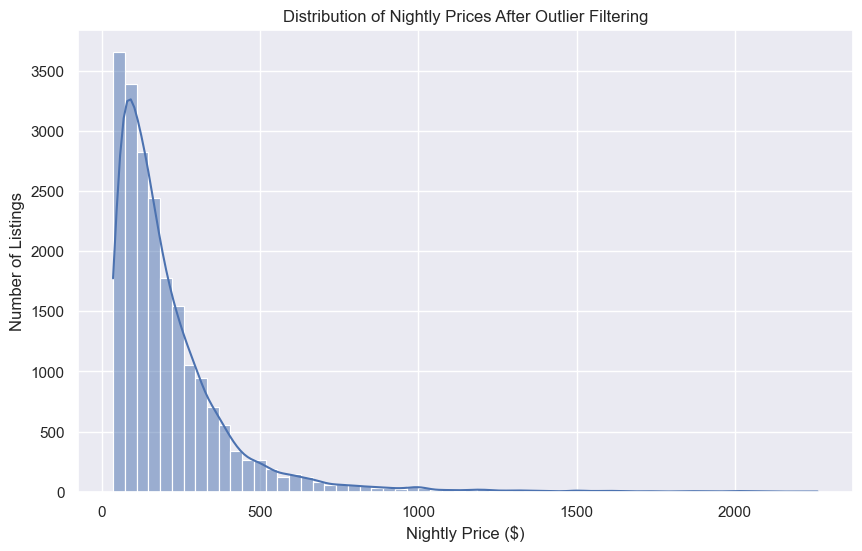

In [7]:
sns.histplot(data["price"], bins=60, kde=True)
plt.title("Distribution of Nightly Prices After Outlier Filtering")
plt.xlabel("Nightly Price ($)")
plt.ylabel("Number of Listings")
plt.show()

In [8]:
# quick distribution diagnostics from the stats material
skew_val = stats.skew(data["price"])
skew_p   = stats.skewtest(data["price"]).pvalue
print(f"Skewness: {skew_val:.2f} (skewtest p-value: {skew_p:.3g})")

Skewness: 3.55 (skewtest p-value: 0)


Even after trimming the top and bottom 1%, the price distribution is still strongly right-skewed (skewness around 3.5, skewtest p-value far below 0.05). This is why the rest of the EDA leans on medians instead of means whenever it compares groups.

### 4.1 Borough Overview

In [9]:
borough_summary = (data.groupby("neighbourhood_group_cleansed")["price"]
                     .agg(["count", "mean", "median"])
                     .sort_values("median", ascending=False))
borough_summary

,count,mean,median
neighbourhood_group_cleansed,,,
Manhattan,9350,283.190588,222.0
Brooklyn,7226,172.821063,135.0
Queens,3324,136.147413,103.0
Staten Island,311,127.437299,100.0
Bronx,800,122.905000,95.0


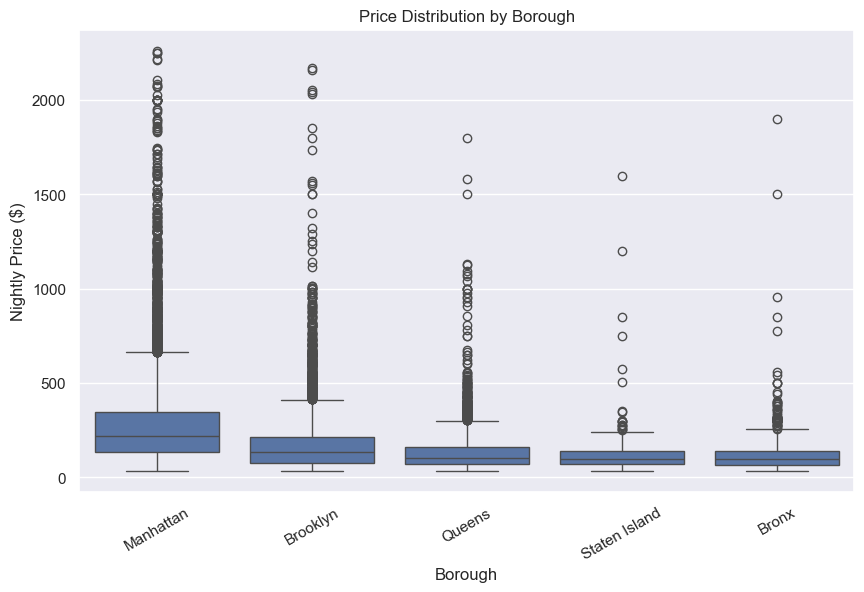

In [10]:
sns.boxplot(data=data, x="neighbourhood_group_cleansed", y="price",
            order=borough_summary.index)
plt.title("Price Distribution by Borough")
plt.xlabel("Borough")
plt.ylabel("Nightly Price ($)")
plt.xticks(rotation=30)
plt.show()

Manhattan has the highest median nightly price (around $222) and Bronx the lowest (around $95), so the Manhattan median is roughly 2.3x the Bronx median. The boxplots also show heavy overlap between boroughs, so borough alone is not enough to predict whether a specific listing is expensive or cheap.

### 4.2 Room Type Within Borough

In [11]:
room_borough = pd.pivot_table(data, values="price",
                              index="neighbourhood_group_cleansed",
                              columns="room_type", aggfunc="median")
room_borough

room_type,Entire home/apt,Hotel room,Private room,Shared room
neighbourhood_group_cleansed,,,,
Bronx,134.0,NaN,70.0,NaN
Brooklyn,188.0,381.0,80.0,115.0
Manhattan,250.0,447.0,117.0,61.0
Queens,155.0,246.5,77.0,103.0
Staten Island,118.0,NaN,80.0,128.0


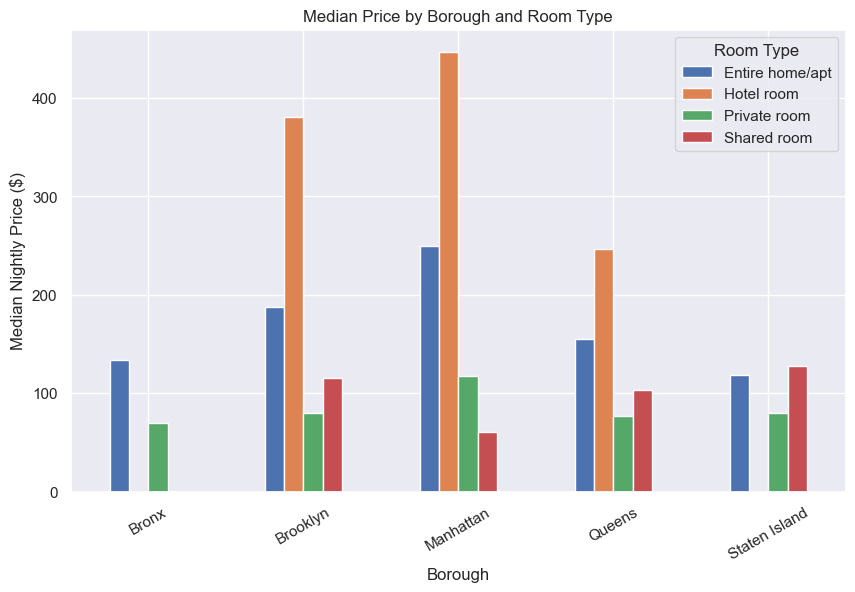

In [12]:
room_borough.plot(kind="bar")
plt.title("Median Price by Borough and Room Type")
plt.xlabel("Borough")
plt.ylabel("Median Nightly Price ($)")
plt.xticks(rotation=30)
plt.legend(title="Room Type")
plt.show()

The entire-home premium over a private room is far from constant: about $133 in Manhattan, $108 in Brooklyn, $78 in Queens, $64 in Bronx, and only $38 in Staten Island. So the same room-type upgrade is worth very different amounts in different boroughs. This is exactly the kind of interaction a single borough average hides.

### 4.3 Guest Capacity

In [13]:
capacity_summary = (data[data["accommodates"] <= 10]
                    .groupby("accommodates")["price"]
                    .agg(["count", "median", "mean"]))
capacity_summary["median_step_up"] = capacity_summary["median"].diff()
capacity_summary

,count,median,mean,median_step_up
accommodates,,,,
1,3558,66.0,83.596402,NaN
2,9618,143.0,189.505303,77.0
3,1676,177.5,202.270883,34.5
4,3274,220.0,277.948992,42.5
5,794,235.5,291.151134,15.5
6,1121,286.0,354.223907,50.5
7,203,307.0,402.004926,21.0
8,436,360.0,448.667431,53.0
9,64,404.0,473.453125,44.0


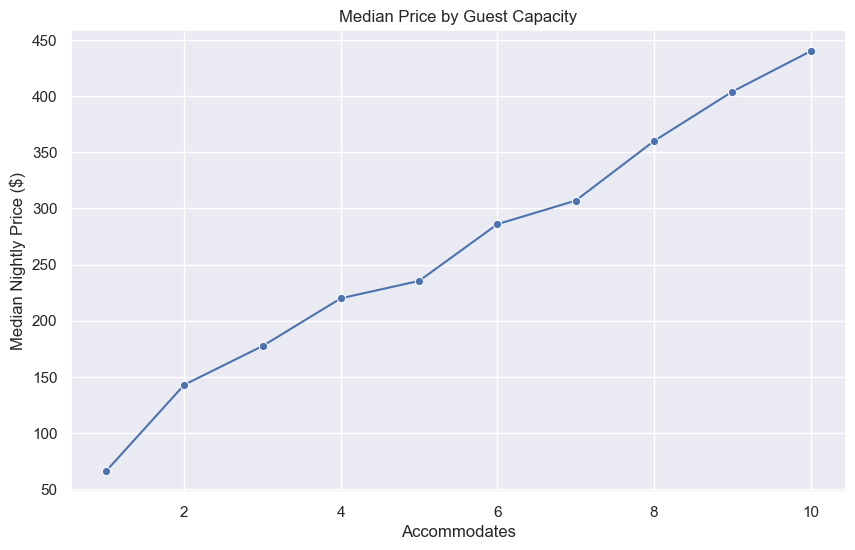

In [14]:
sns.lineplot(data=capacity_summary, x=capacity_summary.index, y="median", marker="o")
plt.title("Median Price by Guest Capacity")
plt.xlabel("Accommodates")
plt.ylabel("Median Nightly Price ($)")
plt.show()

Median price rises with capacity but the per-guest step-up is uneven, so adding more capacity does not give a fixed dollar boost. Listings that accommodate 1-2 guests sit well below the 4+ tier, but the gap between 6 and 10 guests is small relative to the gap between 2 and 4.

### 4.4 Neighborhood Variation Within Boroughs

Boroughs are too coarse on their own: Manhattan contains very expensive neighborhoods like Midtown and the Financial District, but also much cheaper ones like Washington Heights (median around $80). To avoid noisy comparisons, we only keep neighborhoods with at least 100 listings after the price cleaning.

In [15]:
neighborhood_by_borough = (data.groupby(
                                ["neighbourhood_group_cleansed", "neighbourhood_cleansed"])["price"]
                            .agg(count="count", median_price="median", mean_price="mean")
                            .reset_index())

large_neighborhoods = neighborhood_by_borough[neighborhood_by_borough["count"] >= 100].copy()

top_neighborhoods_by_borough = (large_neighborhoods
                                .sort_values(["neighbourhood_group_cleansed", "median_price"],
                                             ascending=[True, False])
                                .groupby("neighbourhood_group_cleansed")
                                .head(5))
top_neighborhoods_by_borough

,neighbourhood_group_cleansed,neighbourhood_cleansed,count,median_price,mean_price
80,Brooklyn,Greenpoint,295,264.0,294.996610
86,Brooklyn,Park Slope,160,200.0,242.537500
62,Brooklyn,Clinton Hill,183,196.0,216.748634
75,Brooklyn,Fort Greene,133,173.0,201.879699
95,Brooklyn,Williamsburg,824,164.0,205.910194
122,Manhattan,Theater District,221,373.0,425.185520
120,Manhattan,SoHo,104,348.5,425.028846
103,Manhattan,Financial District,374,341.5,417.358289
128,Manhattan,West Village,220,314.5,369.450000
114,Manhattan,Midtown,1255,300.0,370.909163


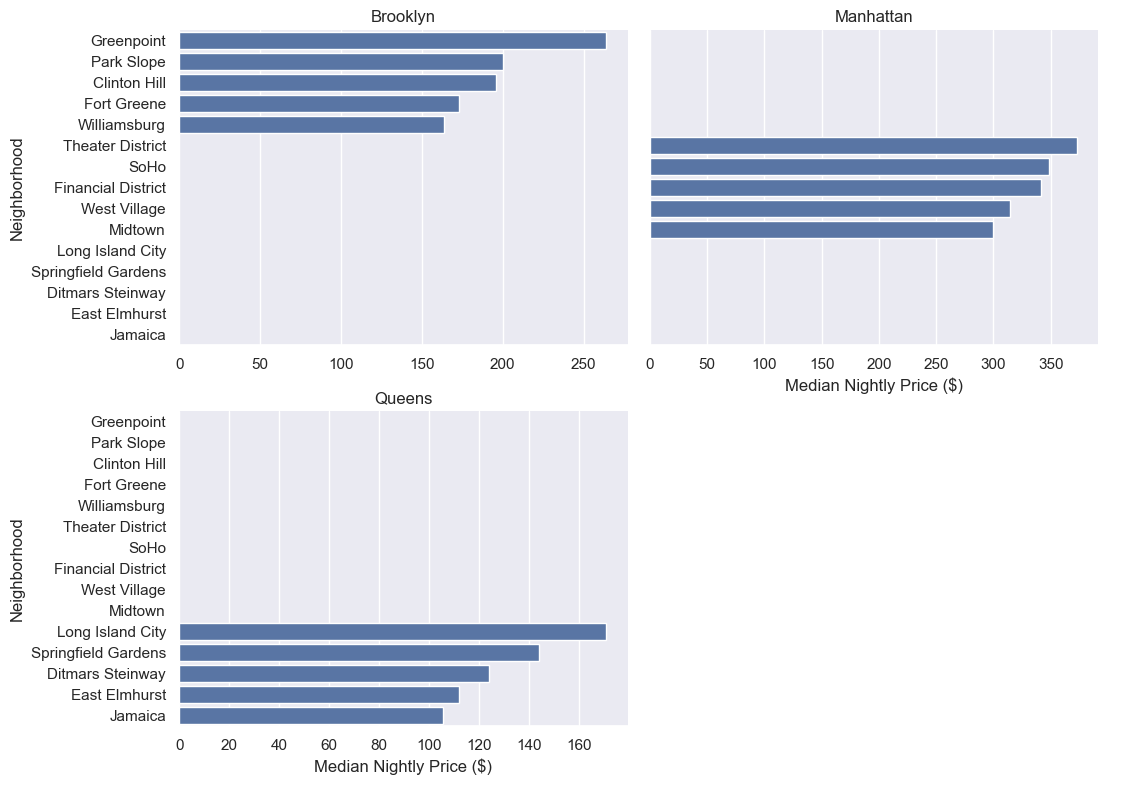

In [16]:
g = sns.catplot(data=top_neighborhoods_by_borough,
                x="median_price", y="neighbourhood_cleansed",
                col="neighbourhood_group_cleansed", col_wrap=2,
                kind="bar", sharex=False, height=4, aspect=1.4)
g.set_axis_labels("Median Nightly Price ($)", "Neighborhood")
g.set_titles("{col_name}")
plt.show()

Within Manhattan, the highest-priced neighborhoods (Midtown, Hell's Kitchen, Theater District) sit far above the borough median, while within Brooklyn, neighborhoods like Williamsburg and DUMBO drive most of the borough's high-end. Bronx and Staten Island are flatter. The takeaway: a host pricing against the "Manhattan median" is using the wrong reference point if their listing is in a much pricier or cheaper neighborhood.

### 4.5 Neighborhood x Room Type

The recommendations below say a host should compare against the same neighborhood **and** the same room type. To support that, we look at median price for the three most-listed neighborhoods in each borough, broken out by room type.

In [17]:
# pick the three biggest neighborhoods inside each borough
biggest = (data.groupby(["neighbourhood_group_cleansed", "neighbourhood_cleansed"])
                .size().reset_index(name="n")
                .sort_values(["neighbourhood_group_cleansed", "n"],
                             ascending=[True, False])
                .groupby("neighbourhood_group_cleansed").head(3))

mask = data.set_index(["neighbourhood_group_cleansed", "neighbourhood_cleansed"]).index.isin(
    list(zip(biggest["neighbourhood_group_cleansed"], biggest["neighbourhood_cleansed"]))
)

nbhd_room = (data[mask]
             .pivot_table(values="price",
                          index=["neighbourhood_group_cleansed", "neighbourhood_cleansed"],
                          columns="room_type", aggfunc="median"))
nbhd_room

room_type                                            Entire home/apt  \
neighbourhood_group_cleansed neighbourhood_cleansed                    
Bronx                        Allerton                          120.0   
                             Wakefield                         141.5   
                             Williamsbridge                     99.0   
Brooklyn                     Bedford-Stuyvesant                175.0   
                             Bushwick                          162.5   
                             Williamsburg                      220.0   
Manhattan                    Hell's Kitchen                    226.0   
                             Midtown                           302.0   
                             Upper East Side                   212.0   
Queens                       Astoria                           168.0   
                             Long Island City                  222.0   
                             Ridgewood                         202.0   
Staten Island                Mariners Harbor                    71.0   
                             St. George                        150.0   
                             Tompkinsville                      98.0   

room_type                                            Hotel room  Private room  \
neighbourhood_group_cleansed neighbourhood_cleansed                             
Bronx                        Allerton                       NaN          78.0   
                             Wakefield                      NaN          73.0   
                             Williamsbridge                 NaN          60.0   
Brooklyn                     Bedford-Stuyvesant             NaN          72.0   
                             Bushwick                       NaN          67.0   
                             Williamsburg                 971.0          92.0   
Manhattan                    Hell's Kitchen               447.0         165.5   
                             Midtown                        NaN         270.0   
                             Upper East Side                NaN         100.5   
Queens                       Astoria                        NaN          80.0   
                             Long Island City             260.0          95.0   
                             Ridgewood                      NaN          66.5   
Staten Island                Mariners Harbor                NaN          72.0   
                             St. George                     NaN          61.0   
                             Tompkinsville                  NaN          80.0   

room_type                                            Shared room  
neighbourhood_group_cleansed neighbourhood_cleansed               
Bronx                        Allerton                        NaN  
                             Wakefield                       NaN  
                             Williamsbridge                  NaN  
Brooklyn                     Bedford-Stuyvesant             96.0  
                             Bushwick                       43.0  
                             Williamsburg                   38.5  
Manhattan                    Hell's Kitchen                 75.0  
                             Midtown                        82.0  
                             Upper East Side               114.0  
Queens                       Astoria                       242.0  
                             Long Island City                NaN  
                             Ridgewood                       NaN  
Staten Island                Mariners Harbor                 NaN  
                             St. George                      NaN  
                             Tompkinsville                   NaN

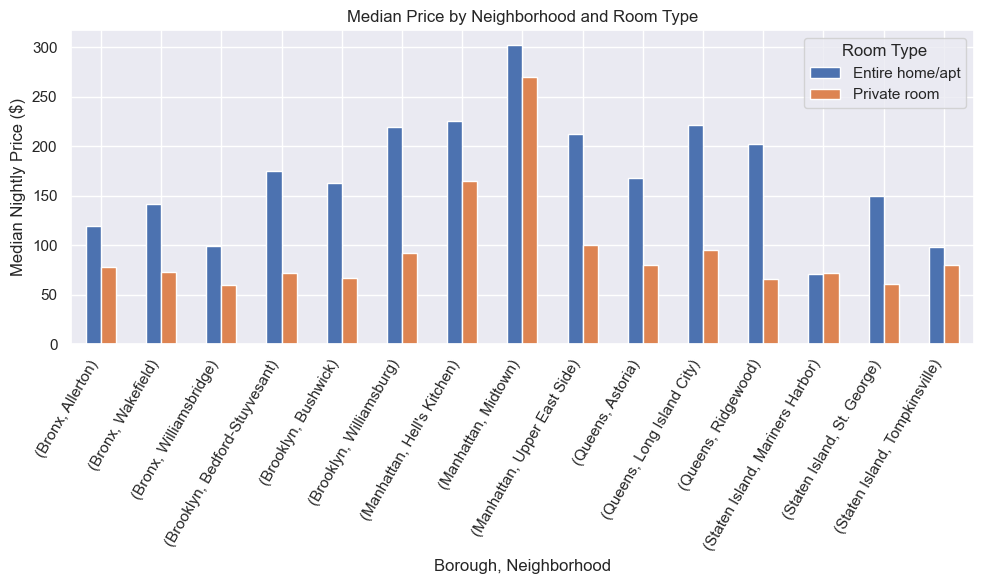

In [18]:
nbhd_room[["Entire home/apt", "Private room"]].plot(kind="bar")
plt.title("Median Price by Neighborhood and Room Type")
plt.xlabel("Borough, Neighborhood")
plt.ylabel("Median Nightly Price ($)")
plt.xticks(rotation=60, ha="right")
plt.legend(title="Room Type")
plt.tight_layout()
plt.show()

Even within one borough, the entire-home / private-room gap shifts a lot from neighborhood to neighborhood. For example, an entire home in Midtown commands a much larger premium over a Midtown private room than the equivalent comparison in Astoria or Bedford-Stuyvesant. Neighborhood + room type together is a much tighter benchmark than borough alone.

### 4.6 Reviews

In [19]:
review_cols = ["price", "number_of_reviews", "reviews_per_month",
               "review_scores_rating", "review_scores_cleanliness",
               "review_scores_location", "review_scores_value"]

data[review_cols].corr(numeric_only=True)["price"].sort_values(ascending=False)

price                        1.000000
review_scores_location       0.107719
reviews_per_month            0.079678
review_scores_cleanliness    0.074739
review_scores_rating         0.044741
review_scores_value          0.004541
number_of_reviews           -0.029055
Name: price, dtype: float64

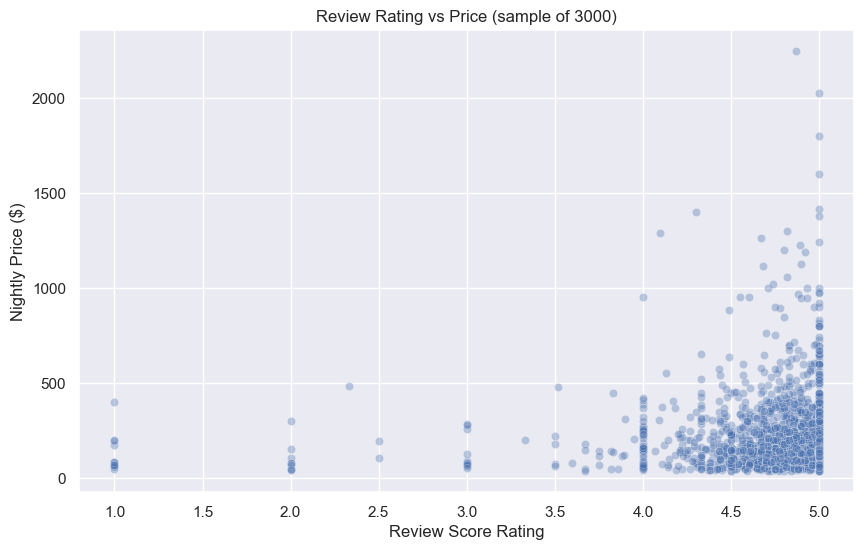

In [20]:
sns.scatterplot(data=data.sample(min(3000, len(data)), random_state=42),
                x="review_scores_rating", y="price", alpha=0.35)
plt.title("Review Rating vs Price (sample of 3000)")
plt.xlabel("Review Score Rating")
plt.ylabel("Nightly Price ($)")
plt.show()

The Pearson correlations between price and the review-related columns are all small: rating ≈ 0.04, cleanliness ≈ 0.07, location ≈ 0.11, value ≈ 0.00. The scatter plot makes the reason clear: most listings sit at very high ratings (4.5+), so the rating column has little spread to explain price differences. Reviews look more like a baseline trust requirement than a strong price lever in this snapshot.

### 4.7 Host Type

In [21]:
data["host_type"] = np.where(data["calculated_host_listings_count"] >= 5,
                              "Professional host", "Small host")

host_summary = (data.groupby("host_type")
                    .agg(listings=("id", "count"),
                         median_price=("price", "median"),
                         mean_price=("price", "mean"),
                         median_availability=("availability_365", "median"),
                         median_minimum_nights=("minimum_nights", "median")))
host_summary

,listings,median_price,mean_price,median_availability,median_minimum_nights
host_type,,,,,
Professional host,8648,179.0,233.396508,304.0,30.0
Small host,12363,148.0,199.687374,270.0,30.0


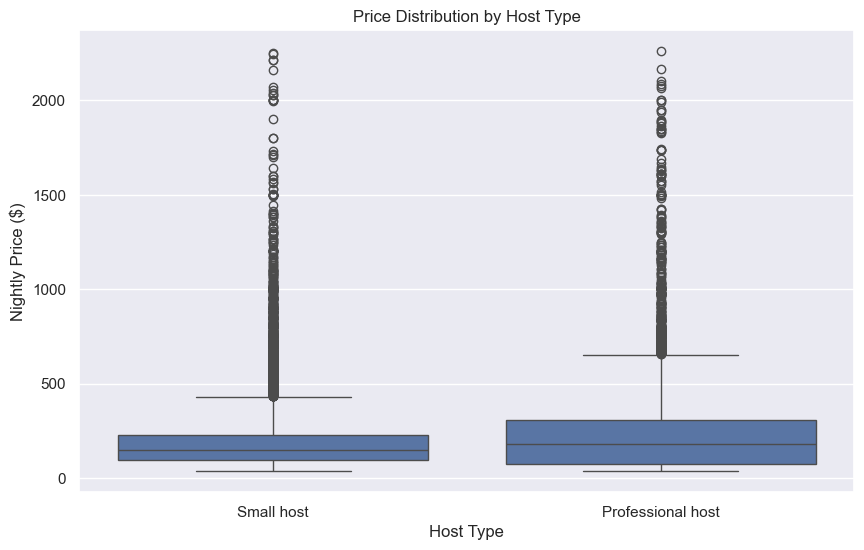

In [22]:
sns.boxplot(data=data, x="host_type", y="price")
plt.title("Price Distribution by Host Type")
plt.xlabel("Host Type")
plt.ylabel("Nightly Price ($)")
plt.show()

Hosts with 5+ listings ("Professional host") tend to have higher availability and slightly different minimum-night patterns than smaller hosts. The price distributions overlap heavily, so this is more a market-segment signal than a strong price predictor on its own.

### 4.8 Numeric Correlations

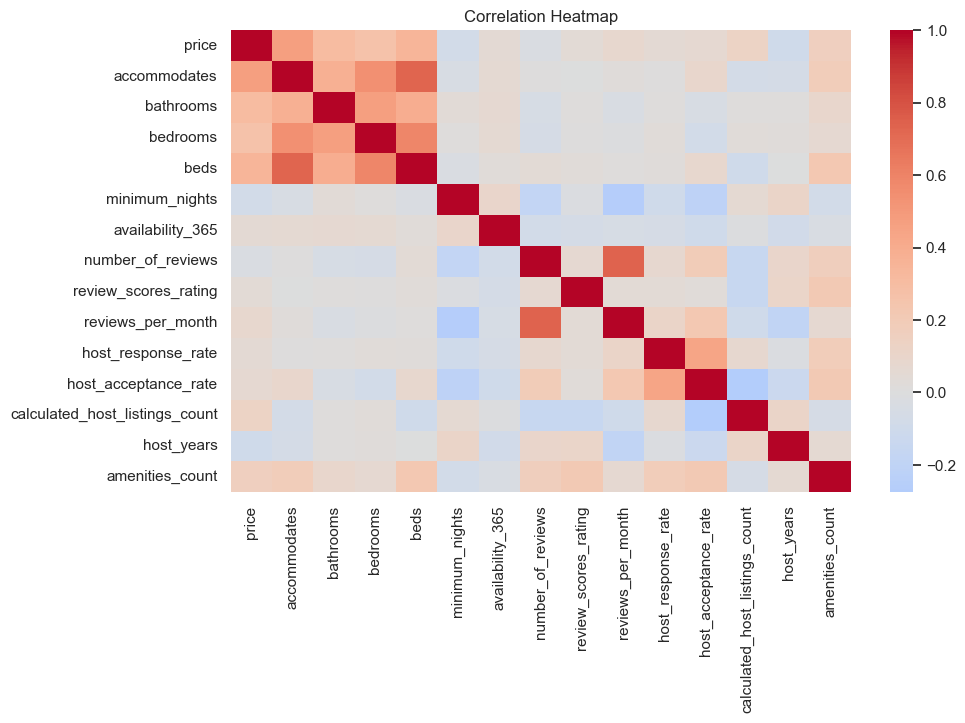

In [23]:
numeric_for_corr = ["price", "accommodates", "bathrooms", "bedrooms", "beds",
                    "minimum_nights", "availability_365", "number_of_reviews",
                    "review_scores_rating", "reviews_per_month",
                    "host_response_rate", "host_acceptance_rate",
                    "calculated_host_listings_count", "host_years", "amenities_count"]

corr = data[numeric_for_corr].corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

Capacity-related variables (`accommodates`, `bedrooms`, `beds`, `bathrooms`) are highly correlated with each other and are the strongest linear correlates of price. Review variables form a tight cluster with weak correlations to price. This collinearity is one reason a regularized linear model (Ridge / Lasso) can be more stable than plain linear regression on this feature set.

## 5. Statistical Tests

Two tests. The first uses one-way ANOVA to check whether the five borough means differ at all. The second zooms in on a specific business question with a two-sample Welch t-test: inside Manhattan, do entire homes and private rooms really have different mean prices? Picking ANOVA for the 3+ group case and a t-test for the two-group case follows the rule from class.

### 5.1 ANOVA: borough mean prices

- **H0:** mean nightly price is the same across all five boroughs.
- **H1:** at least one borough has a different mean price.
- **α = 0.05.**

In [24]:
borough_groups = [g["price"].values
                  for _, g in data.groupby("neighbourhood_group_cleansed")]

f_stat, p_val = stats.f_oneway(*borough_groups)
print(f"F-statistic: {f_stat:.2f}")
print(f"p-value:     {p_val:.3g}")

if p_val < 0.05:
    print("Reject H0: borough mean prices are not all equal.")
else:
    print("Fail to reject H0.")

F-statistic: 570.42
p-value:     0
Reject H0: borough mean prices are not all equal.


The p-value is essentially zero, so we reject H0: borough mean prices are not all equal.

One important caveat: with ~21,000 listings, even tiny mean differences will produce a vanishing p-value. So statistical significance here is almost guaranteed regardless of effect size. The practical magnitudes from the EDA (Manhattan median ≈ $222 vs Bronx ≈ $95) are what actually matter. The test confirms the difference is real; it does not tell us whether it is large.

### 5.2 t-test: Manhattan entire home vs private room

The EDA flagged that the entire-home / private-room gap inside Manhattan is large. A Welch (unequal-variance) two-sample t-test is the standard check for whether two groups have the same mean.

- **H0:** mean Manhattan entire-home price equals mean Manhattan private-room price.
- **H1:** the two means differ.
- **α = 0.05.**

In [25]:
mn = data[data["neighbourhood_group_cleansed"] == "Manhattan"]
mn_entire  = mn.loc[mn["room_type"] == "Entire home/apt", "price"]
mn_private = mn.loc[mn["room_type"] == "Private room",    "price"]

t_stat, t_p = stats.ttest_ind(mn_entire, mn_private, equal_var=False)

print(f"Entire home:  n={len(mn_entire)}, mean=${mn_entire.mean():.2f}")
print(f"Private room: n={len(mn_private)}, mean=${mn_private.mean():.2f}")
print(f"Mean difference: ${mn_entire.mean() - mn_private.mean():.2f}")
print(f"Welch t-statistic: {t_stat:.2f}")
print(f"p-value:           {t_p:.3g}")

if t_p < 0.05:
    print("Reject H0: Manhattan entire-home and private-room means differ.")
else:
    print("Fail to reject H0.")

Entire home:  n=6897, mean=$309.94
Private room: n=2384, mean=$204.72
Mean difference: $105.22
Welch t-statistic: 18.63
p-value:           1.89e-74
Reject H0: Manhattan entire-home and private-room means differ.


We reject H0: the mean Manhattan entire-home price (around $310) is about $105 higher than the mean private-room price (around $205). The same large-sample caveat from 5.1 applies here — with ~9,000 Manhattan listings the p-value goes to essentially zero even for small gaps — but in this case the dollar difference itself is large, which is the substantive part of the result.

Note that this test deliberately conditions on Manhattan. Section 4.2 already showed the entire-home / private-room gap shrinks sharply in cheaper boroughs (only ~$38 in Staten Island), so the same t-test on the full city would mix two effects.

## 6. Machine Learning Setup

The target is `price`. We use a mix of location, room type, property type, capacity, host, availability, review, and engineered features. Models stay within course scope:

1. **Median baseline** — predicts the training median for every listing. Sets the floor.
2. **Linear regression** — simplest model in the regression family.
3. **Ridge regression** — L2 regularized linear model; better behaved when features are correlated.
4. **Lasso regression** — L1 regularized; can shrink coefficients to zero, useful with many one-hot dummies.
5. **Decision tree regressor** — non-linear, handles interactions but can overfit.
6. **Random forest regressor** — bagged trees; usually more stable than a single tree.

Reported metrics:
- **MAE** — average absolute prediction error in dollars (easiest to interpret).
- **RMSE** — penalizes larger errors more heavily.
- **R²** — share of price variance the model explains.

In [26]:
features = ["neighbourhood_group_cleansed", "neighbourhood_cleansed",
            "room_type", "property_type",
            "accommodates", "bathrooms", "bedrooms", "beds",
            "minimum_nights", "maximum_nights",
            "availability_30", "availability_60", "availability_90", "availability_365",
            "number_of_reviews", "number_of_reviews_ltm",
            "review_scores_rating", "review_scores_cleanliness",
            "review_scores_location", "review_scores_value",
            "reviews_per_month",
            "host_response_rate", "host_acceptance_rate",
            "host_is_superhost", "host_identity_verified", "instant_bookable",
            "calculated_host_listings_count", "host_years",
            "has_license", "amenities_count"]

model_data = data[features + ["price"]].copy()
X = model_data[features]
y = model_data["price"]

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical:", categorical_features)
print("Numeric:    ", len(numeric_features), "columns")

Categorical: ['neighbourhood_group_cleansed', 'neighbourhood_cleansed', 'room_type', 'property_type']
Numeric:     26 columns


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

In [28]:
def fit_and_score(name, model):
    pipe = Pipeline([("pre", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    return {
        "Model": name,
        "MAE":  mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2":   r2_score(y_test, pred),
        "pipeline": pipe,
    }

RF_PARAMS = dict(n_estimators=100, max_depth=18, random_state=42)

results = [
    fit_and_score("Median baseline",   DummyRegressor(strategy="median")),
    fit_and_score("Linear regression", LinearRegression()),
    fit_and_score("Ridge",             Ridge(alpha=1.0)),
    fit_and_score("Lasso",             Lasso(alpha=0.5, max_iter=10000)),
    fit_and_score("Decision tree",     DecisionTreeRegressor(max_depth=12, random_state=42)),
    fit_and_score("Random forest",     RandomForestRegressor(**RF_PARAMS)),
]

metrics = (pd.DataFrame([{k: r[k] for k in ("Model", "MAE", "RMSE", "R2")}
                         for r in results])
             .sort_values("MAE")
             .reset_index(drop=True))
metrics

,Model,MAE,RMSE,R2
0,Random forest,61.034053,129.610255,0.612515
1,Decision tree,73.695391,157.231420,0.429764
2,Ridge,85.930868,153.488369,0.456591
3,Linear regression,86.047102,153.495958,0.456537
4,Lasso,88.442894,157.560300,0.427376
5,Median baseline,122.088032,217.314273,-0.089313


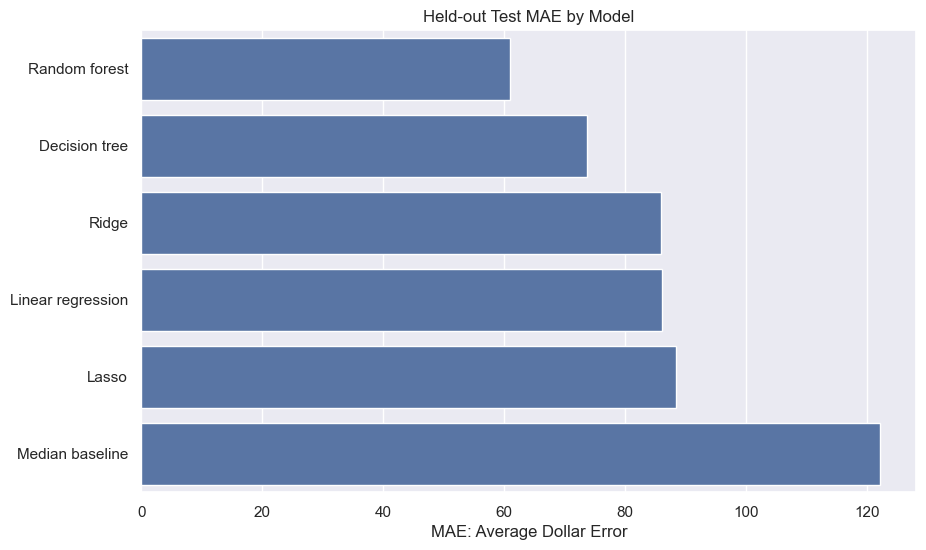

In [29]:
sns.barplot(data=metrics, x="MAE", y="Model")
plt.title("Held-out Test MAE by Model")
plt.xlabel("MAE: Average Dollar Error")
plt.ylabel("")
plt.show()

All four real models beat the median baseline by a clear margin, so the features carry real signal. Random forest gives the lowest held-out MAE; the linear models (Linear / Ridge / Lasso) are close to each other and clearly behind the trees. A single decision tree is in between. This is consistent with price depending on combinations of features (neighborhood + room type + capacity) rather than a clean linear sum.

## 7. Cross-Validation

A single train / test split can be lucky or unlucky. K-fold cross-validation gives a more stable estimate by averaging over multiple folds. We run 5-fold CV on the **training set only** so that the held-out test set above stays untouched. The Random Forest configuration is the same as in section 6.

In [30]:
cv_models = [
    ("Linear regression", LinearRegression()),
    ("Ridge",             Ridge(alpha=1.0)),
    ("Lasso",             Lasso(alpha=0.5, max_iter=10000)),
    ("Decision tree",     DecisionTreeRegressor(max_depth=12, random_state=42)),
    ("Random forest",     RandomForestRegressor(**RF_PARAMS)),
]

cv_rows = []
for name, model in cv_models:
    pipe = Pipeline([("pre", preprocessor), ("model", model)])
    mae_scores = -cross_val_score(pipe, X_train, y_train, cv=5,
                                  scoring="neg_mean_absolute_error")
    r2_scores  =  cross_val_score(pipe, X_train, y_train, cv=5,
                                  scoring="r2")
    cv_rows.append({
        "Model":       name,
        "CV MAE mean": mae_scores.mean(),
        "CV MAE std":  mae_scores.std(),
        "CV R2 mean":  r2_scores.mean(),
        "CV R2 std":   r2_scores.std(),
    })

cv_metrics = pd.DataFrame(cv_rows).sort_values("CV MAE mean").reset_index(drop=True)
cv_metrics

,Model,CV MAE mean,CV MAE std,CV R2 mean,CV R2 std
0,Random forest,62.067937,1.841633,0.609189,0.034903
1,Decision tree,75.903164,1.645724,0.371341,0.049641
2,Ridge,82.392235,1.162225,0.499633,0.026412
3,Linear regression,82.618642,1.147165,0.497850,0.027767
4,Lasso,84.368202,1.342937,0.476181,0.020885


The cross-validated rankings line up with the single-split results from section 6: random forest first, then decision tree, then the linear family. The CV MAE standard deviations are small relative to the means, so the model ordering is stable across folds, not an artifact of one lucky split.

## 8. Feature Importance

Random forest can report which features it relied on most. These importances reflect predictive usefulness inside this model; they are not a causal claim about what determines price.

In [31]:
rf_pipeline = next(r["pipeline"] for r in results if r["Model"] == "Random forest")

onehot_names = (rf_pipeline.named_steps["pre"]
                            .named_transformers_["cat"]
                            .named_steps["onehot"]
                            .get_feature_names_out(categorical_features))
all_feature_names = numeric_features + list(onehot_names)

importances = rf_pipeline.named_steps["model"].feature_importances_

importance_df = (pd.DataFrame({"feature": all_feature_names,
                               "importance": importances})
                   .sort_values("importance", ascending=False)
                   .reset_index(drop=True))
importance_df.head(20)

,feature,importance
0,accommodates,0.179342
1,bathrooms,0.124449
2,neighbourhood_group_cleansed_Manhattan,0.074372
3,calculated_host_listings_count,0.073451
4,amenities_count,0.048769
5,minimum_nights,0.046349
6,host_years,0.045846
7,availability_365,0.022139
8,availability_90,0.021110
9,host_acceptance_rate,0.020754


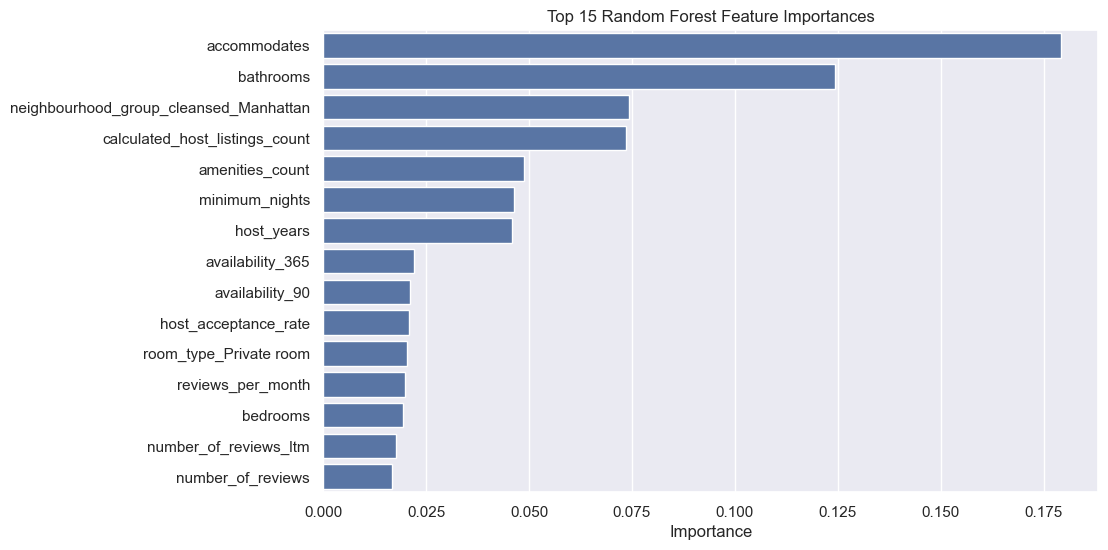

In [32]:
top_importance = importance_df.head(15)
sns.barplot(data=top_importance, x="importance", y="feature")
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("")
plt.show()

The top features line up with what the EDA suggested: capacity dominates (`accommodates`, `bathrooms`, with `bedrooms` and `beds` further down), followed by a borough-level location flag (`neighbourhood_group_cleansed_Manhattan` is third, but no specific `neighbourhood_cleansed_*` column makes the top 20 — the model compresses location into 'Manhattan vs the rest'), host-scale columns (`calculated_host_listings_count`, `host_years`), and the engineered `amenities_count`. The first room-type column to appear is `room_type_Private room` at rank 11, and the highest-ranked review column, `review_scores_location`, only shows up at rank 16. The other review-score columns (`rating`, `cleanliness`, `value`) drop out of the top 20 entirely. That ranking matches the weak review-price correlations from section 4.6, which is a useful internal consistency check between the EDA and the model.

## 9. Main Insights

1. **Borough matters but is too coarse.** Manhattan's median ($222) is about 2.3x Bronx's ($95), but the boxplots overlap heavily and within-borough neighborhood medians vary by tens of dollars. Borough is a useful first cut, not a benchmark.

2. **The entire-home premium is location-dependent.** Choosing "entire home over private room" is worth about $133 in Manhattan, $108 in Brooklyn, $78 in Queens, $64 in Bronx, and only $38 in Staten Island. A flat statement like "entire homes cost more" misses this large interaction.

3. **Capacity raises price unevenly.** Bigger listings cost more, but the marginal step from 6 to 10 guests is much smaller than the step from 2 to 4. The relationship is not linear, which is part of why tree models outperform linear models here.

4. **Review scores barely move price.** Correlations with price are small (rating ≈ 0.04, location ≈ 0.11). Most listings already cluster near the top of the rating scale, so high reviews look more like a basic trust requirement than a meaningful pricing lever.

5. **Random forest wins on this feature set.** It clearly beats the median baseline and beats the linear models on both held-out MAE and 5-fold CV MAE. The most likely reason is that price depends on combinations of features (neighborhood × room type × capacity), which trees handle natively.

6. **Feature importance lines up with the EDA story.** Capacity columns and the Manhattan borough flag dominate the random forest's top features; review scores rank far below, with only `review_scores_location` making it into the top 20. Specific neighborhood dummies do not appear in the top 20 at all — the model relies on the coarser Manhattan flag rather than the 200+ neighborhood columns. Same direction as the correlations and the borough / neighborhood EDA, even though the model was free to use any feature.


## 10. Host-Facing Recommendations

- Benchmark against the same **neighborhood + room type**, not just borough. Section 4.5 shows the entire-home / private-room gap shifts a lot between neighborhoods inside the same borough.
- Treat borough medians as a first sanity check, not a target.
- When evaluating whether to add a bedroom or bump capacity, compare the median price *step* at the relevant capacity level (section 4.3) rather than assuming a constant per-guest premium.
- Do not expect a higher rating to translate into a meaningfully higher price. Strong reviews matter for getting booked at all, but they are not a major price differentiator in this snapshot.
- If the goal is short-stay tourist demand, room type, capacity, and neighborhood matter more than host-side variables. Host availability and minimum-nights settings are mostly market-segment signals.

## 11. Limitations

- **Listed price, not booked revenue.** The dataset is a snapshot of advertised nightly prices, not actual bookings or occupancy.
- **Large share of missing prices.** About 41% of raw listings have no price field and are dropped. The remaining sample skews toward listings that were active and priced at the snapshot date.
- **Outlier filter.** We trim the bottom and top 1% of prices, so conclusions describe typical listings, not luxury rentals or data-entry errors.
- **No time component.** Seasonality, holidays, big events, and competitor price changes are invisible in a single snapshot.
- **Association, not causation.** A high feature importance does not mean changing that feature will move price.
- **Many neighborhoods, sparse cells.** Section 4.5 only uses the largest neighborhoods. Smaller neighborhoods are too thin for stable medians.

## 12. Conclusion

Borough alone is the wrong unit for pricing decisions. Once we drop down to neighborhood + room type, the structure of the market becomes much clearer: the entire-home / private-room gap, the marginal value of capacity, and the irrelevance of review scores all emerge. Among course-scope models, random forest gives the best predictions on both a held-out test set and 5-fold CV, consistent with the non-linear, interaction-heavy structure that the EDA already suggested. The model's own feature importance ranking lines up with that EDA story, which is the most useful kind of validation here: the data, the test, and the model all point the same way.